In [1]:
import numpy as np

#### Activation Functions Implementations
- Sigmoid, LeakyReLU (param. negative_slope), SELU

In [2]:
class Sigmoid:
    def __init__(self):
        self.output = None

    def forward(self, x):
        self.output = 1 / (1 + np.exp(-x))
        return self.output

    def backward(self, grad_output):
        return grad_output * self.output * (1 - self.output)

class LeakyReLU:
    def __init__(self, negative_slope=0.01):
        self.mask = None
        self.negative_slope = negative_slope

    def forward(self, x):
        self.mask = (x > 0)
        return np.where(self.mask, x, self.negative_slope * x)

    def backward(self, grad_output):
        return grad_output * np.where(self.mask, 1, self.negative_slope)

class SELU:
    def __init__(self):
        self.x = None
        self.alpha = 1.6732632423543772848170429916717
        self.scale = 1.0507009873554804934193349852946

    def forward(self, x):
        self.x = x
        return self.scale * np.where(x > 0, x, self.alpha * (np.exp(x) - 1))

    def backward(self, grad_output):
        return grad_output * self.scale * np.where(self.x > 0, 1, self.alpha * np.exp(self.x))

#### Linear Layer Implementation

In [3]:
class Linear:
    def __init__(self, in_features, out_features, bias=True):
        self.grad_bias = None
        self.grad_weights = None
        self.x = None
        self.weights = np.random.randn(out_features, in_features) * np.sqrt(2. / in_features)
        self.bias = np.zeros(out_features) if bias else None

    def forward(self, x):
        self.x = x
        return x @ self.weights.T + (self.bias if self.bias is not None else 0)

    def backward(self, grad_output):
        self.grad_weights = grad_output.T @ self.x
        self.grad_bias = grad_output.sum(axis=0) if self.bias is not None else None
        return grad_output @ self.weights

    def update(self, optimizer):
        optimizer.update(self.weights, self.grad_weights)
        if self.bias is not None:
            optimizer.update(self.bias, self.grad_bias)

#### Conv2D Layer Implementation

In [4]:
class Conv2d:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        self.x = None
        self.kernel_size = (kernel_size, kernel_size) if isinstance(kernel_size, int) else kernel_size
        self.stride = stride
        self.padding = padding
        self.weights = np.random.randn(out_channels, in_channels, *self.kernel_size) * np.sqrt(
            2 / (in_channels * np.prod(self.kernel_size)))
        self.bias = np.zeros(out_channels) if bias else None
        self.grad_weights = None
        self.grad_bias = None

    def _im2col(self, x):
        x_padded = np.pad(x, ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')
        N, C, H, W = x_padded.shape
        KH, KW = self.kernel_size
        out_h = (H - KH) // self.stride + 1
        out_w = (W - KW) // self.stride + 1

        cols = np.zeros((N, C, KH, KW, out_h, out_w))
        for h in range(KH):
            h_start = h * self.stride
            h_end = h_start + out_h * self.stride
            for w in range(KW):
                w_start = w * self.stride
                w_end = w_start + out_w * self.stride
                cols[:, :, h, w, :, :] = x_padded[:, :, h_start:h_end:self.stride, w_start:w_end:self.stride]
        return cols.transpose(0, 4, 5, 1, 2, 3).reshape(N * out_h * out_w, -1)

    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        out_channels, _, KH, KW = self.weights.shape

        # Calculate output dimensions
        out_h = (H + 2 * self.padding - KH) // self.stride + 1
        out_w = (W + 2 * self.padding - KW) // self.stride + 1

        cols = self._im2col(x)
        W_col = self.weights.reshape(out_channels, -1).T

        out = cols @ W_col
        out = out.reshape(N, out_h, out_w, out_channels).transpose(0, 3, 1, 2)

        if self.bias is not None:
            out += self.bias.reshape(1, -1, 1, 1)
        return out

    def backward(self, grad_output):
        out_channels, _, KH, KW = self.weights.shape
        grad_input = np.zeros_like(self.x)

        # Calculate gradient with respect to weights
        cols = self._im2col(self.x)
        grad_output_reshaped = grad_output.transpose(0, 2, 3, 1).reshape(-1, out_channels)
        self.grad_weights = grad_output_reshaped.T @ cols
        self.grad_weights = self.grad_weights.reshape(self.weights.shape)

        # Calculate gradient with respect to bias
        if self.bias is not None:
            self.grad_bias = grad_output.sum(axis=(0, 2, 3))

        # Calculate gradient with respect to input
        W_col = self.weights.reshape(out_channels, -1)
        grad_output_cols = grad_output_reshaped @ W_col
        grad_input = self._col2im(grad_output_cols, self.x.shape, self.kernel_size, self.stride, self.padding)

        return grad_input

    def _col2im(self, cols, x_shape, kernel_size, stride, padding):
        N, C, H, W = x_shape
        KH, KW = kernel_size
        out_h = (H + 2 * padding - KH) // stride + 1
        out_w = (W + 2 * padding - KW) // stride + 1

        cols_reshaped = cols.reshape(N, out_h, out_w, C, KH, KW).transpose(0, 3, 4, 5, 1, 2)
        x_padded = np.zeros((N, C, H + 2 * padding, W + 2 * padding))

        for h in range(KH):
            for w in range(KW):
                h_start = h * stride
                h_end = h_start + out_h * stride
                w_start = w * stride
                w_end = w_start + out_w * stride
                x_padded[:, :, h_start:h_end:stride, w_start:w_end:stride] += cols_reshaped[:, :, h, w, :, :]

        if padding == 0:
            return x_padded
        return x_padded[:, :, padding:-padding, padding:-padding]

    def update(self, optimizer):
        optimizer.update(self.weights, self.grad_weights)
        if self.bias is not None:
            optimizer.update(self.bias, self.grad_bias)

#### MaxPool2D Layer Implementation

In [5]:
class MaxPool2d:
    def __init__(self, kernel_size, stride=None):
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.x = None
        self.mask = None

    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        KH, KW = self.kernel_size, self.kernel_size
        out_h = (H - KH) // self.stride + 1
        out_w = (W - KW) // self.stride + 1

        out = np.zeros((N, C, out_h, out_w))
        self.mask = np.zeros_like(x)

        for i in range(out_h):
            for j in range(out_w):
                h_start = i * self.stride
                w_start = j * self.stride
                x_slice = x[:, :, h_start:h_start + KH, w_start:w_start + KW]
                out[:, :, i, j] = np.max(x_slice, axis=(2, 3))
                max_mask = (x_slice == out[:, :, i, j][:, :, None, None])
                self.mask[:, :, h_start:h_start + KH, w_start:w_start + KW] += max_mask

        return out

    def backward(self, grad_output):
        grad = np.zeros_like(self.x)
        N, C, H, W = self.x.shape
        KH, KW = self.kernel_size, self.kernel_size
        out_h = (H - KH) // self.stride + 1
        out_w = (W - KW) // self.stride + 1

        for i in range(out_h):
            for j in range(out_w):
                h_start = i * self.stride
                w_start = j * self.stride
                grad[:, :, h_start:h_start + KH, w_start:w_start + KW] += grad_output[:, :, i, j][:, :, None, None] * self.mask[:, :, h_start:h_start + KH, w_start:w_start + KW]

        return grad

#### Dropout Layer Implementation

In [6]:
class Dropout:
    def __init__(self, p=0.5):
        self.p = p
        self.mask = None

    def forward(self, x, training=True):
        if training:
            self.mask = np.random.binomial(1, 1 - self.p, size=x.shape) / (1 - self.p)
            return x * self.mask
        return x

    def backward(self, grad_output):
        return grad_output * self.mask

#### BatchNorm Layer Implementation

In [ ]:
class BatchNorm2d:
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        self.x_norm = None
        self.std = None
        self.x_centered = None
        self.x = None
        self.gamma = np.ones(num_features)
        self.beta = np.zeros(num_features)
        self.eps = eps
        self.momentum = momentum
        self.running_mean = np.zeros(num_features)
        self.running_var = np.ones(num_features)
        self.grad_gamma = None
        self.grad_beta = None
        self.batch_size = 0
        self.num_features = num_features

    def forward(self, x, training=True):
        self.x = x
        N, C, H, W = x.shape
        self.batch_size = N * H * W
        
        if training:
            batch_mean = x.mean(axis=(0, 2, 3))
            batch_var = x.var(axis=(0, 2, 3))

            self.running_mean = self.momentum * batch_mean + (1 - self.momentum) * self.running_mean
            self.running_var = self.momentum * batch_var + (1 - self.momentum) * self.running_var

            self.x_centered = x - batch_mean.reshape(1, -1, 1, 1)
            self.std = np.sqrt(batch_var + self.eps)
            self.x_norm = self.x_centered / self.std.reshape(1, -1, 1, 1)
        else:
            x_centered = x - self.running_mean.reshape(1, -1, 1, 1)
            self.x_norm = x_centered / np.sqrt(self.running_var + self.eps).reshape(1, -1, 1, 1)

        return self.gamma.reshape(1, -1, 1, 1) * self.x_norm + self.beta.reshape(1, -1, 1, 1)

    def backward(self, grad_output):
        N, C, H, W = grad_output.shape
        
        self.grad_beta = np.sum(grad_output, axis=(0, 2, 3))
        
        self.grad_gamma = np.sum(grad_output * self.x_norm, axis=(0, 2, 3))
        
        dx_norm = grad_output * self.gamma.reshape(1, -1, 1, 1)
        
        dvar = np.sum(dx_norm * self.x_centered * (-0.5) * (self.std.reshape(1, -1, 1, 1) ** -3), axis=(0, 2, 3))
        
        dmean = np.sum(dx_norm * (-1 / self.std.reshape(1, -1, 1, 1)), axis=(0, 2, 3))
        dmean += dvar * np.mean(-2 * self.x_centered, axis=(0, 2, 3))
        
        dx = dx_norm / self.std.reshape(1, -1, 1, 1)
        dx += dvar.reshape(1, -1, 1, 1) * 2 * self.x_centered / (N * H * W)
        dx += dmean.reshape(1, -1, 1, 1) / (N * H * W)
        
        return dx

    def update(self, optimizer):
        optimizer.update(self.gamma, self.grad_gamma)
        optimizer.update(self.beta, self.grad_beta)

#### Loss Function Implementation

In [ ]:
class FocalLoss:
    def __init__(self, alpha=0.25, gamma=2):
        self.alpha = alpha
        self.gamma = gamma
        self.probs = None
        self.targets = None

    def forward(self, logits, targets):
        logits_shifted = logits - np.max(logits, axis=1, keepdims=True)
        self.probs = np.exp(logits_shifted) / np.exp(logits_shifted).sum(axis=1, keepdims=True)
        self.probs = np.clip(self.probs, 1e-10, 1.0)
        
        batch_size = logits.shape[0]
        self.targets = targets
        probs = self.probs[np.arange(batch_size), targets]
        focal = -self.alpha * (1 - probs) ** self.gamma * np.log(probs)
        return focal.mean()

    def backward(self, logits, targets):
        batch_size = logits.shape[0]
        num_classes = logits.shape[1]
        
        one_hot = np.zeros((batch_size, num_classes))
        one_hot[np.arange(batch_size), targets] = 1
        
        probs = np.clip(self.probs, 1e-10, 1.0)
        pt = np.sum(probs * one_hot, axis=1)
        
        focal_weight = self.alpha * (1 - pt) ** self.gamma
        dx = probs - one_hot
        dx = dx * focal_weight.reshape(-1, 1)
        dx = dx / batch_size
        
        return dx

#### Optimizer Implementation

In [ ]:
class SGD:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.velocity = {}

    def update(self, param, grad):
        if param not in self.velocity:
            self.velocity[param] = np.zeros_like(grad)
        self.velocity[param] = self.momentum * self.velocity[param] + grad
        param -= self.lr * self.velocity[param]

class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0001):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.m = {}
        self.v = {}
        self.t = 0

    def update(self, param, grad):
        self.t += 1
        param_id = id(param)  
        
        if self.weight_decay > 0:
            grad = grad + self.weight_decay * param

        if param_id not in self.m:
            self.m[param_id] = np.zeros_like(param)
            self.v[param_id] = np.zeros_like(param)

        self.m[param_id] = self.beta1 * self.m[param_id] + (1 - self.beta1) * grad
        self.v[param_id] = self.beta2 * self.v[param_id] + (1 - self.beta2) * (grad ** 2)

        m_hat = self.m[param_id] / (1 - self.beta1 ** self.t)
        v_hat = self.v[param_id] / (1 - self.beta2 ** self.t)

        update = self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        update = np.clip(update, -1.0, 1.0)  
        param -= update

#### Data Loading (Using PyTorch)

In [ ]:
from torchvision import datasets, transforms
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

#### Network Architecture

In [ ]:
class MNIST_CNN:
    def __init__(self):
        # Conv Block 1
        self.conv1 = Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = BatchNorm2d(32)
        self.act1 = LeakyReLU(negative_slope=0)  # Equivalent to ReLU
        self.pool1 = MaxPool2d(kernel_size=2)

        # Conv Block 2
        self.conv2 = Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = BatchNorm2d(64)
        self.act2 = LeakyReLU(0)
        self.pool2 = MaxPool2d(2)

        # Conv Block 3
        self.conv3 = Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = BatchNorm2d(128)
        self.act3 = LeakyReLU(0)
        self.pool3 = MaxPool2d(2)

        # FC Layers
        self.fc1 = Linear(128 * 3 * 3, 512)  # Corrected flattened size
        self.act4 = LeakyReLU(0)
        self.dropout = Dropout(p=0.2)
        self.fc2 = Linear(512, 10)

    def forward(self, x, training=None):
        if training is None:
            training = self.training
        
        # Block 1
        x = self.conv1.forward(x)
        x = self.bn1.forward(x, training)
        x = self.act1.forward(x)
        x = self.pool1.forward(x)

        # Block 2
        x = self.conv2.forward(x)
        x = self.bn2.forward(x, training)
        x = self.act2.forward(x)
        x = self.pool2.forward(x)

        # Block 3
        x = self.conv3.forward(x)
        x = self.bn3.forward(x, training)
        x = self.act3.forward(x)
        x = self.pool3.forward(x)

        # Classifier
        x = x.reshape(x.shape[0], -1)  # Flatten
        x = self.fc1.forward(x)
        x = self.act4.forward(x)
        x = self.dropout.forward(x, training)
        x = self.fc2.forward(x)
        return x

    def backward(self, grad_output):
        # Backprop through all layers
        grad = self.fc2.backward(grad_output)
        grad = self.dropout.backward(grad)
        grad = self.act4.backward(grad)
        grad = self.fc1.backward(grad)

        grad = grad.reshape(-1, 128, 3, 3)  # Corrected reshape size
        grad = self.pool3.backward(grad)
        grad = self.act3.backward(grad)
        grad = self.bn3.backward(grad)
        grad = self.conv3.backward(grad)

        grad = self.pool2.backward(grad)
        grad = self.act2.backward(grad)
        grad = self.bn2.backward(grad)
        grad = self.conv2.backward(grad)

        grad = self.pool1.backward(grad)
        grad = self.act1.backward(grad)
        grad = self.bn1.backward(grad)
        grad = self.conv1.backward(grad)

        return grad

    def train(self):
        self.training = True

    def eval(self):
        self.training = False

#### Training Setup and Training Loop

In [ ]:
model = MNIST_CNN()
criterion = FocalLoss(alpha=1, gamma=2)  
optimizer = Adam(lr=0.0005, weight_decay=0.0001)  

# ================== Training Loop ================== #
num_epochs = 32
losses = []
accuracies = []

for epoch in range(num_epochs):
    # Training
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    total_batches = len(train_loader)
    
    for batch_idx, batch in enumerate(train_loader):
        x, y = batch
        x = x.numpy()
        y = y.numpy()

        # Forward
        logits = model.forward(x, training=True)
        loss = criterion.forward(logits, y)

        # Backward
        grad = criterion.backward(logits, y)
        model.backward(grad)

        # Update parameters
        layers = [model.conv1, model.bn1, model.conv2, model.bn2,
                 model.conv3, model.bn3, model.fc1, model.fc2]
                 
        for layer in layers:
            if hasattr(layer, 'update'):
                layer.update(optimizer)

        epoch_loss += loss
        num_batches += 1

    epoch_loss = epoch_loss / num_batches  
    losses.append(epoch_loss)
    
    # Evaluation
    model.eval()
    correct = 0
    total = 0
    for batch in test_loader:
        x, y = batch
        x = x.numpy()
        y = y.numpy()

        logits = model.forward(x, training=False)
        preds = np.argmax(logits, axis=1)
        correct += (preds == y).sum()
        total += len(y)

    accuracy = correct / total
    accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch 1/32, Loss: 0.0733, Accuracy: 0.9770
Epoch 2/32, Loss: 0.0260, Accuracy: 0.9849
Epoch 3/32, Loss: 0.0190, Accuracy: 0.9874
Epoch 4/32, Loss: 0.0157, Accuracy: 0.9907
Epoch 5/32, Loss: 0.0132, Accuracy: 0.9793
Epoch 6/32, Loss: 0.0127, Accuracy: 0.9913
Epoch 7/32, Loss: 0.0109, Accuracy: 0.9887
Epoch 8/32, Loss: 0.0105, Accuracy: 0.9882
Epoch 9/32, Loss: 0.0091, Accuracy: 0.9847
Epoch 10/32, Loss: 0.0097, Accuracy: 0.9920
Epoch 11/32, Loss: 0.0083, Accuracy: 0.9889
Epoch 12/32, Loss: 0.0077, Accuracy: 0.9914
Epoch 13/32, Loss: 0.0091, Accuracy: 0.9883
Epoch 14/32, Loss: 0.0070, Accuracy: 0.9904
Epoch 15/32, Loss: 0.0073, Accuracy: 0.9894
Epoch 16/32, Loss: 0.0071, Accuracy: 0.9914
Epoch 17/32, Loss: 0.0066, Accuracy: 0.9923
Epoch 18/32, Loss: 0.0066, Accuracy: 0.9896
Epoch 19/32, Loss: 0.0060, Accuracy: 0.9905
Epoch 20/32, Loss: 0.0063, Accuracy: 0.9933
Epoch 21/32, Loss: 0.0065, Accuracy: 0.9909
Epoch 22/32, Loss: 0.0057, Accuracy: 0.9915
Epoch 23/32, Loss: 0.0056, Accuracy: 0.98

#### Visualization of Loss and Accuracy

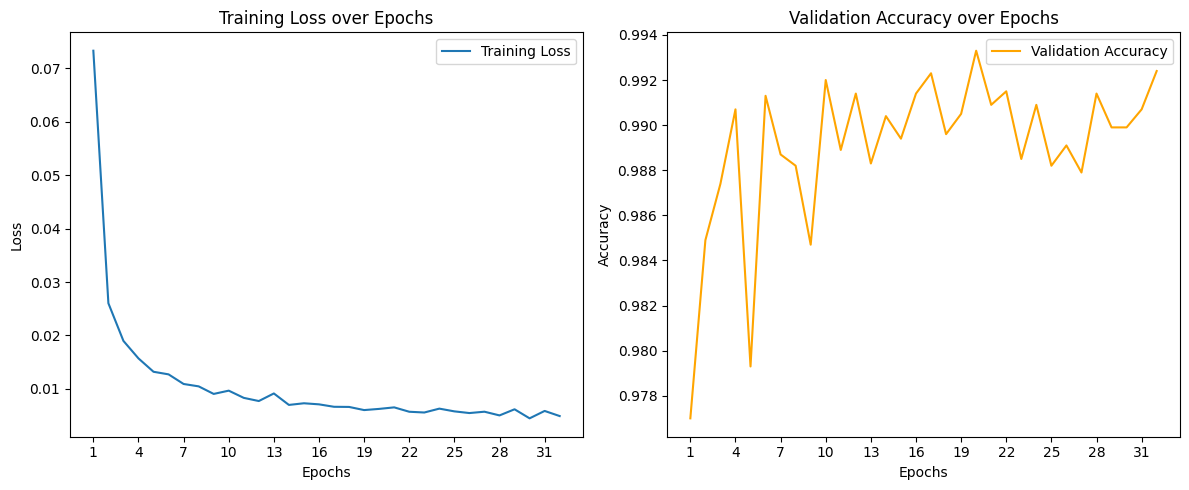

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), losses, label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(1, num_epochs + 1, num_epochs // 10))  
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), accuracies, label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(range(1, num_epochs + 1, num_epochs // 10))  
plt.legend()

plt.tight_layout()
plt.show()